# Звёзды Geant4: детекция и 3D-гипотезы

Новый эксперимент по постановке из переписки. Исходные ноутбуки сохранены.

**Результат:** детекция F1 ≈ 0,919 на отложенных событиях по слабой MC-разметке.
Точное 3D-восстановление пока не решено: IoU достраивания ≈ 0,127.
Подробности — [STAR_RECONSTRUCTION_REPORT.md](STAR_RECONSTRUCTION_REPORT.md).

Ноутбук проверяет сохранённый протокол, читает результаты и запускает один
пример реконструкции. Для полной сборки из исходных файлов см. README.
Метки звёзд основаны на совместном рождении длинных треков; ParentID отсутствует.

In [1]:
import json
from pathlib import Path
import numpy as np
import joblib
from IPython.display import display, Markdown, Image
from reconstruction.protocol import verify_protocol
from reconstruction.core import projections_from_hits
from reconstruction.star_reconstruct import run_event

protocol = verify_protocol()
manifest = json.loads(Path('results/dataset_manifest.json').read_text())
detection = json.loads(Path('results/star_test.json').read_text())
reconstruction = json.loads(Path('results/reconstruction44_test_search_0.3.json').read_text())
print('Версия:', protocol['version'])
print('Категории 20 000 событий:', manifest['categories'])
print('Все контрольные суммы зафиксированных артефактов совпали.')

Версия: stars-v1
Категории 20 000 событий: {'multi_prong': 8617, 'transportation': 9101, 'other_interaction': 2093, 'unresolved': 189}
Все контрольные суммы зафиксированных артефактов совпали.


## Отложенная оценка

Ниже 3 556 событий с двумя проекциями и определённой меткой. Для реконструкции
отдельно взяты 600 событий, в том числе 200 звёзд. Частоты классов в этих двух
проверках различаются: реконструкционная проба намеренно сбалансирована.

| Метрика | Значение |
|---|---:|
| Precision | 0.878 |
| Recall | 0.963 |
| F1 | 0.919 |
| Ложные срабатывания среди других взаимодействий | 55.8% |
| IoU 3D прямых ветвей, с учётом пропусков | 0.048 |
| IoU 3D достраивания, с учётом пропусков | 0.127 |
| Медиана уточнённой ошибки вершины | 19.62 мм |


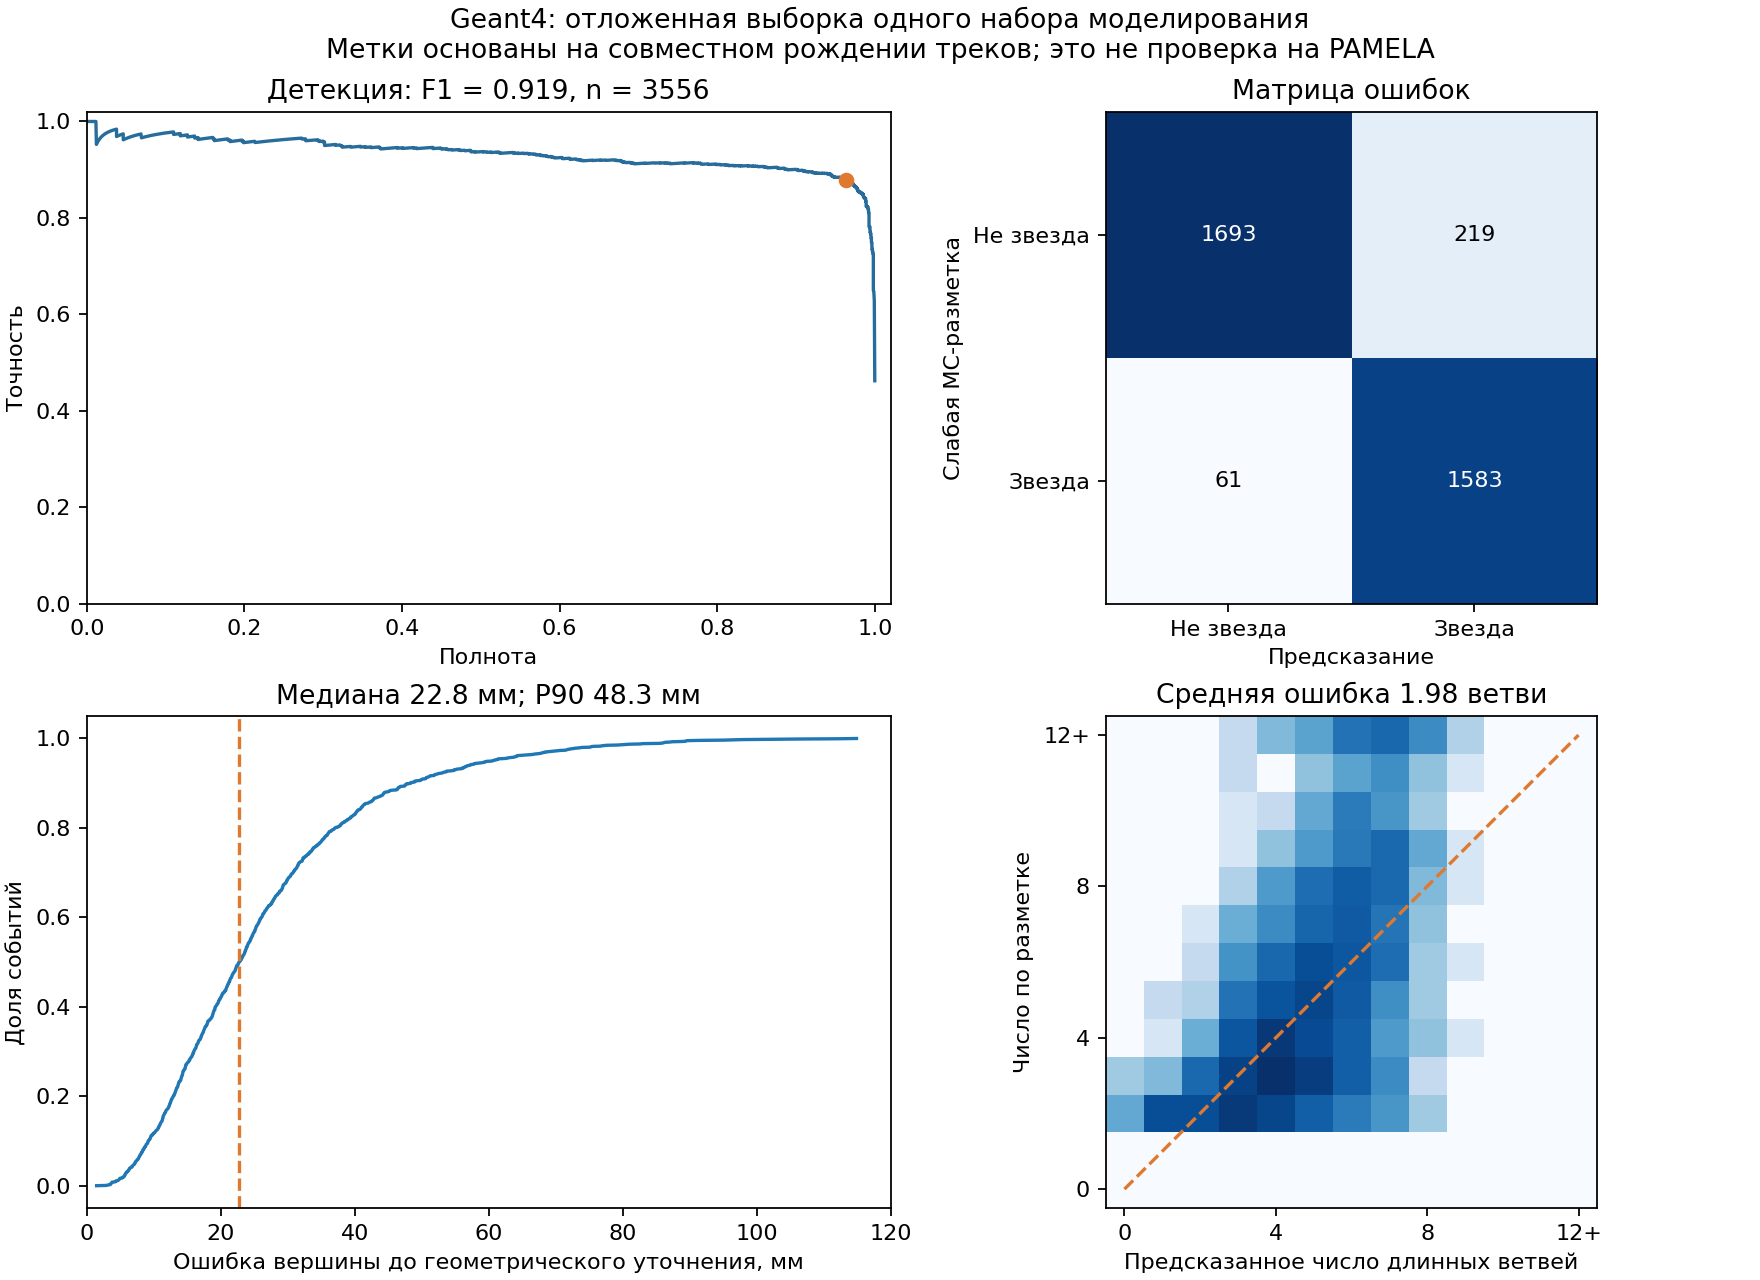

In [2]:
d = detection['detection']
r = reconstruction['summary']['multi_prong']
display(Markdown(f"""| Метрика | Значение |
|---|---:|
| Precision | {d['precision']:.3f} |
| Recall | {d['recall']:.3f} |
| F1 | {d['f1']:.3f} |
| Ложные срабатывания среди других взаимодействий | {100*detection['strata']['other_interaction']['false_positive_rate']:.1f}% |
| IoU 3D прямых ветвей, с учётом пропусков | {r['mean_voxel_iou44_misses_zero']:.3f} |
| IoU 3D достраивания, с учётом пропусков | {r['mean_completion_iou44_misses_zero']:.3f} |
| Медиана уточнённой ошибки вершины | {r['median_refined_vertex_error_mm']:.2f} мм |
"""))
display(Image(filename='results/star_test_dashboard.png'))

## Один пример: антипротон, событие 1476 из validation

В оптимизацию попадают только `xz` и `yz`. Полные 3D-попадания доступны
отдельно для оценки. Пример выбран на 75-м процентиле качества достраивания
среди 16 validation-звёзд; это иллюстрация, а не случайная итоговая оценка.

In [3]:
data = np.load('data/raw/calorimeter_response (2).npy', allow_pickle=True).item()
xz, yz = projections_from_hits(data, 1476)
model = joblib.load('results/star_model.joblib')
event = run_event(model, xz, yz)
result = event['reconstruction']
print('Счёт детектора:', round(event['proposal']['probability'], 3))
print('Вершина:', result['vertex_mm'])
print('Предсказано ветвей / сопоставлено:', event['proposal']['branch_count'], result['matched_branches'])
print('Вариантов сопоставления:', result['pairing_count'])
print('Почти равноценных вариантов:', result['near_optimal_pairings'])
print('Приор достраивания:', result['completion_info']['method'])
print('Измеренные проекционные MSE:', result['completion_info']['observed_xz_mse'], result['completion_info']['observed_yz_mse'])

Счёт детектора: 0.896
Вершина: [6.1, 113.44, 11.184999999999999]
Предсказано ветвей / сопоставлено: 4 4
Вариантов сопоставления: 24
Почти равноценных вариантов: 23
Приор достраивания: interpolated unmeasured marginal + track/continuity transport prior
Измеренные проекционные MSE: 1.2500135684562338e-35 4.790638174173898e-35


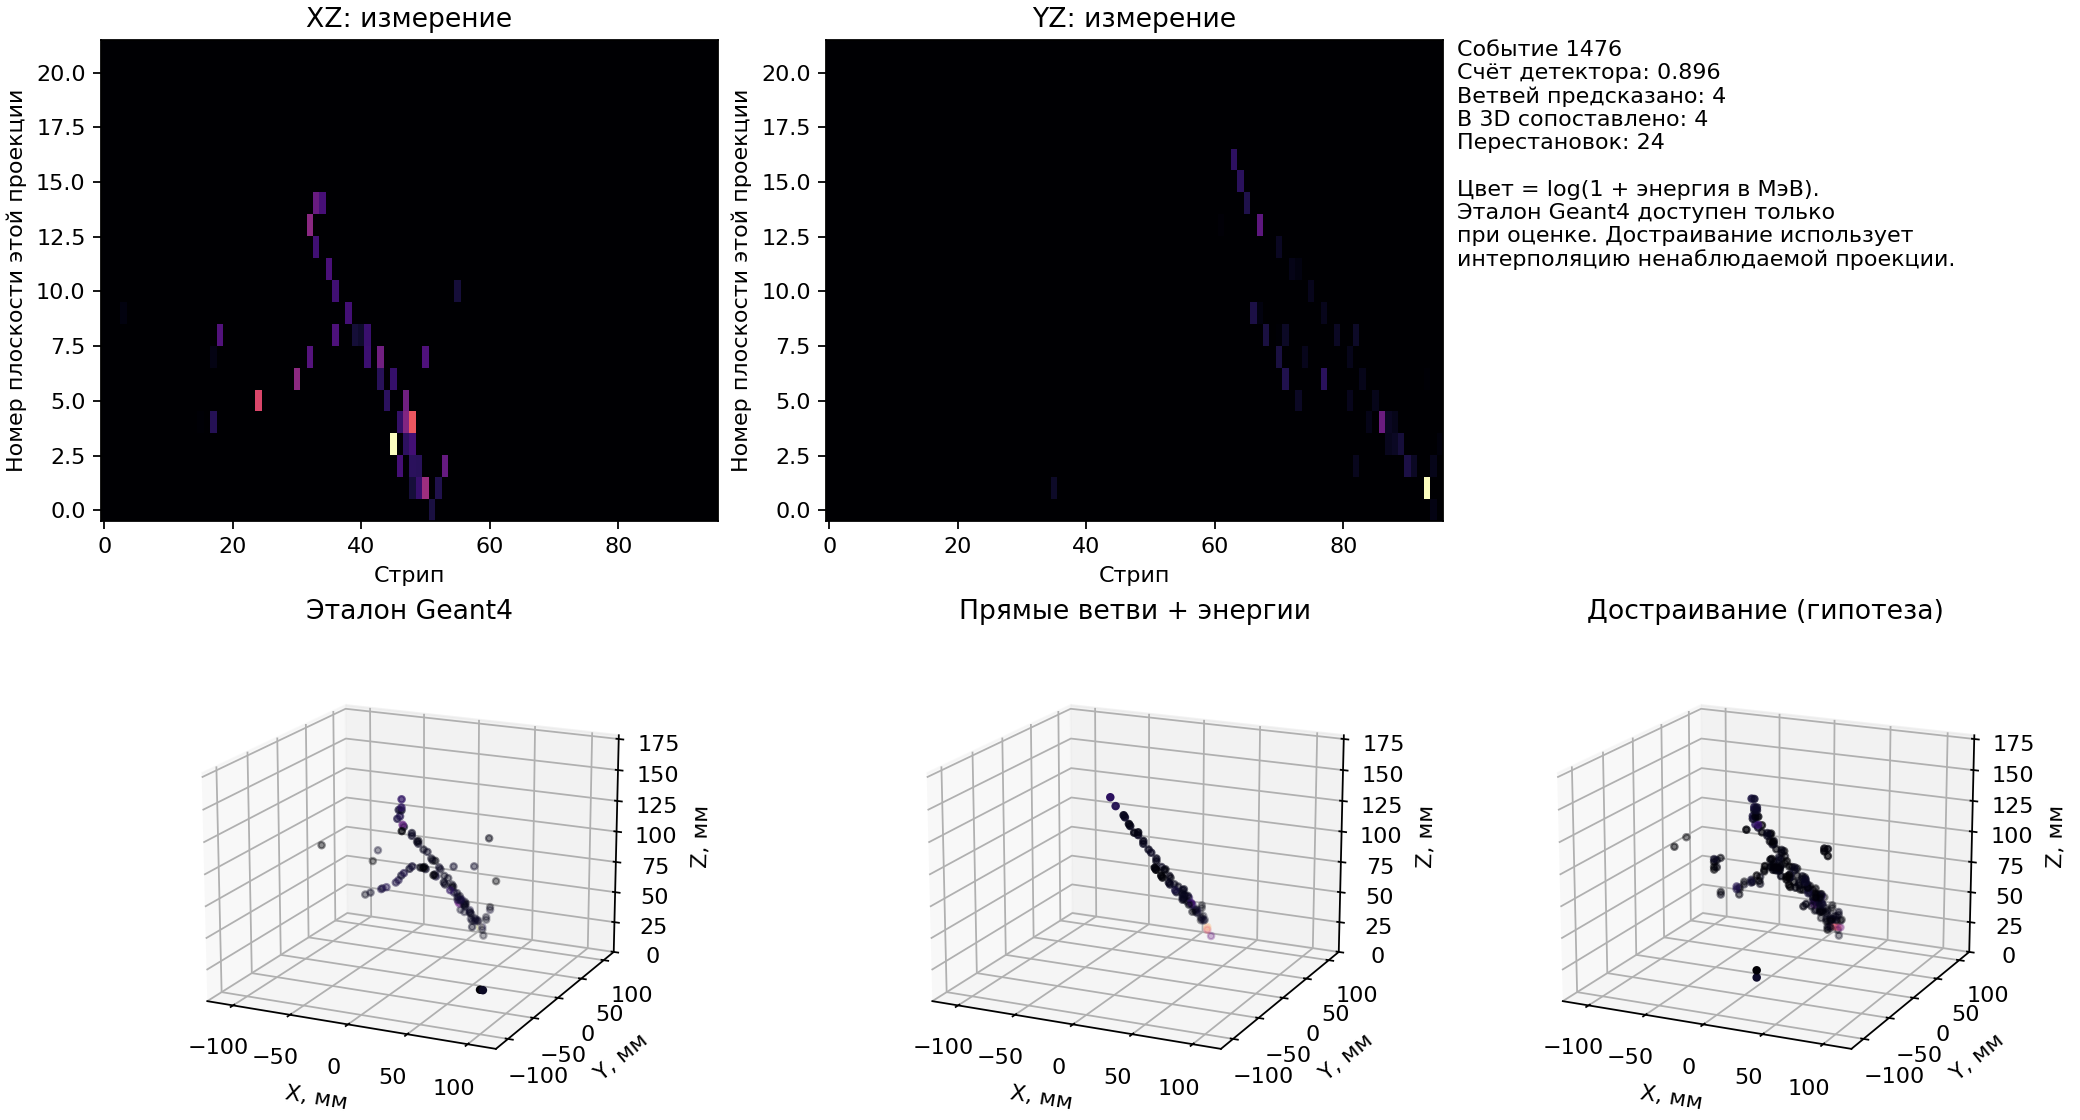

Более слабый пример, 25-й процентиль validation:


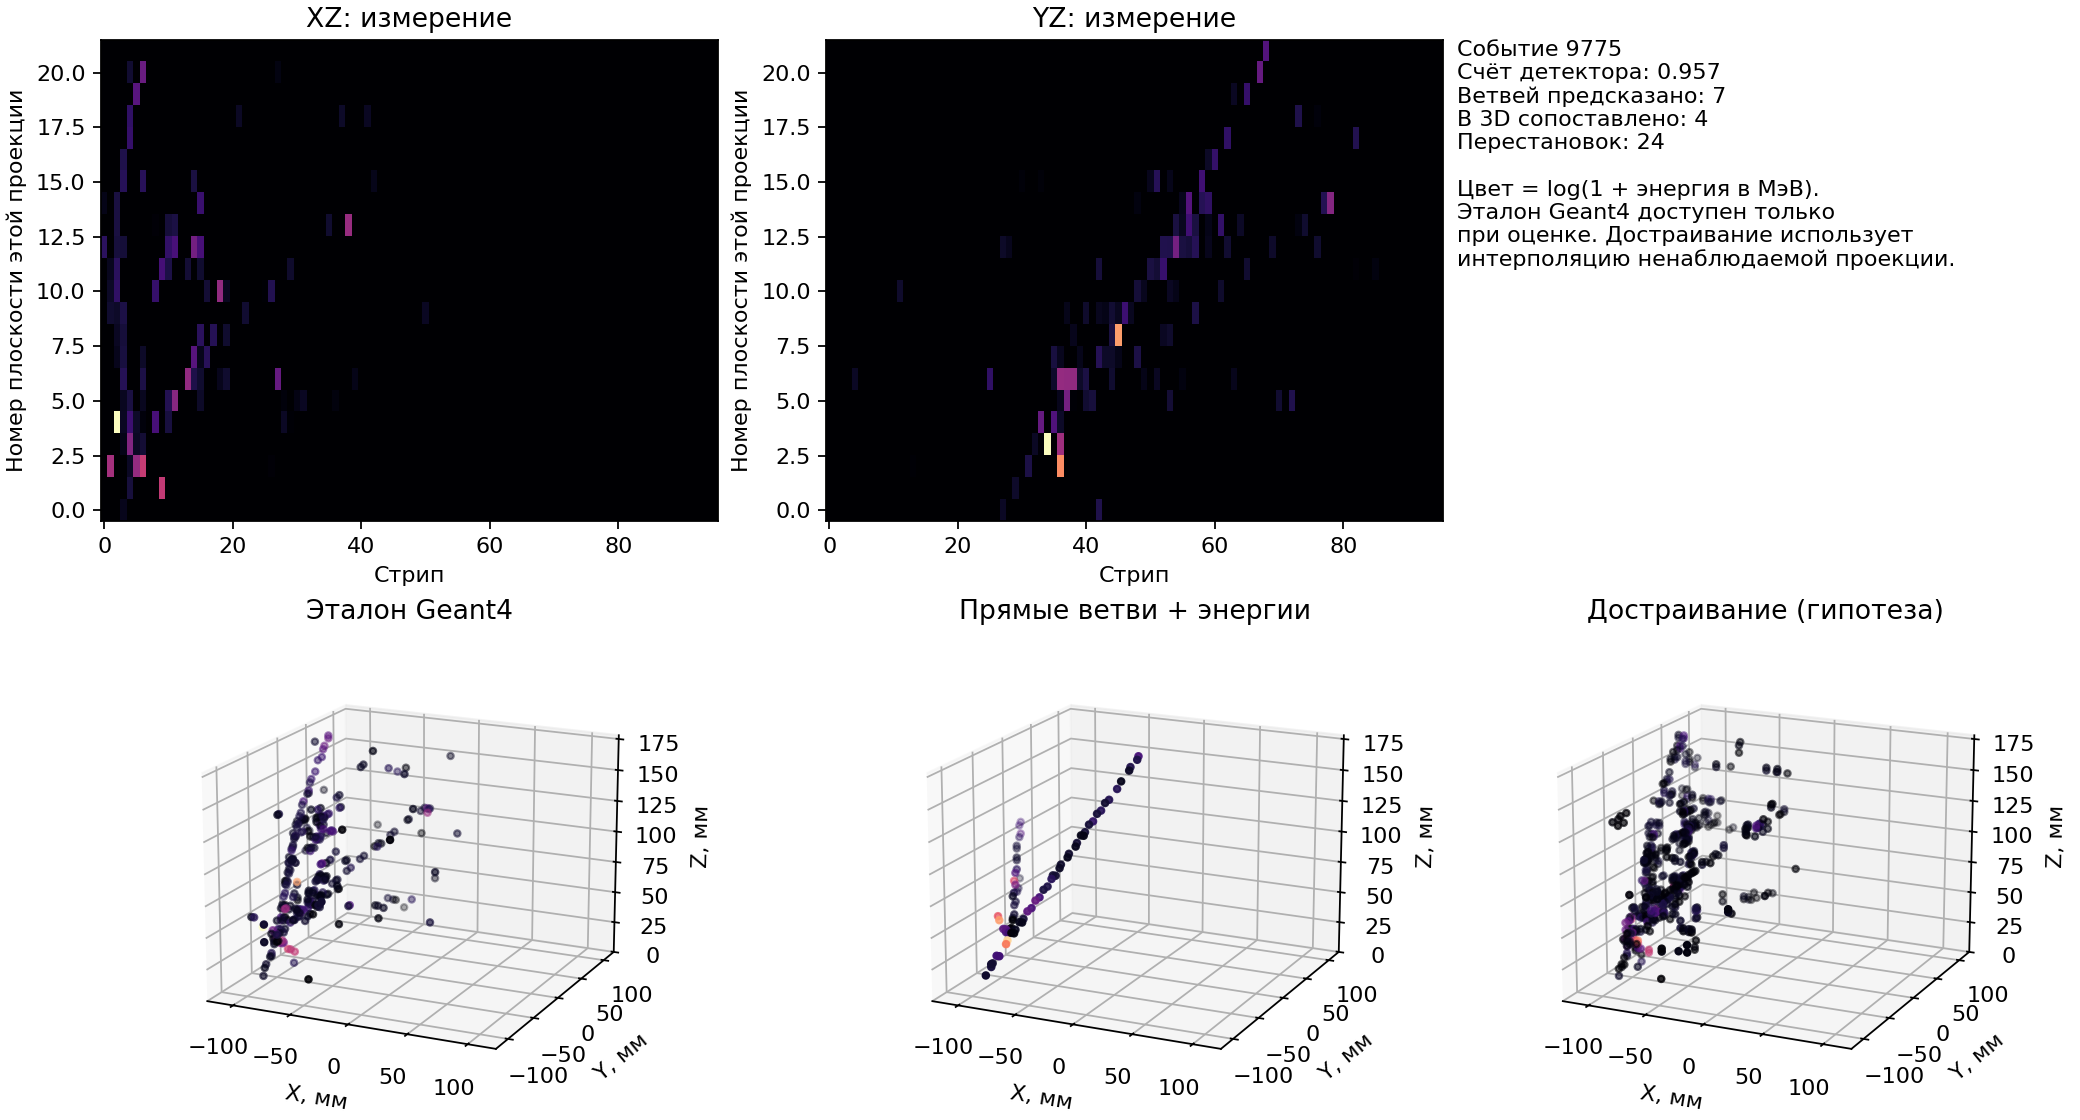

In [4]:
display(Image(filename='results/star_example_upper.png'))
print('Более слабый пример, 25-й процентиль validation:')
display(Image(filename='results/star_example_lower.png'))

## Как читать результат

- Почти нулевая ошибка измеренных проекций у достраивания обеспечивается
  ограничениями транспортной задачи. Она **не доказывает** правильность 3D.
- Достраиваемая координата опирается на интерполяцию соседних плоскостей.
- Максимум четыре прямые ветви недостаточен для многих событий; слившиеся
  ветви и вторичные ливни пока описываются плохо.
- У 118 из 195 найденных тестовых звёзд несколько почти равноценных сопоставлений.
- Уточнение вершины снижает медиану ошибки, но увеличивает среднюю из-за
  крупных промахов. Нужны более устойчивые критерии.
- Следующие шаги: проверить наблюдаемость ветвей и ParentID, выделять конечные
  треки с изломами, отдельно оценивать топологию и неопределённость.

Текущий test уже просмотрен: при изменении разметки или подборе модели по этим
ошибкам нужна новая версия эксперимента и новая независимая проверка.